
# 7.7: Parallelism: Using the Joblib backend

This example demonstrates how to use the Joblib backend for simulating dipoles using `hnn_core`.

`hnn_core` can take advantage of [the Joblib library](https://joblib.readthedocs.io/en/stable/) to run **multiple** *independent* simulations simultaneously across **multiple** CPU processors. This is an example of ["embarrassingly parallel" processing jobs](https://en.wikipedia.org/wiki/Embarrassingly_parallel). In HNN, this is commonly done if you want to run many "trials" of the same simulation. Since each trial simulation is fully independent of the other trial simulations, each trial simulation can be run on its own CPU core. Joblib parallelism is particularly useful if you are using [batch simulation to explore parameter spaces](https://jonescompneurolab.github.io/textbook/content/08_using_hnn_api/batch_simulation.html).

Note that Joblib parallelism is distinct from `hnn_core`'s use of [MPI parallelism, which can be found here](https://jonescompneurolab.github.io/textbook/content/08_using_hnn_api/parallelism_mpi.html).

Authors:

- Mainak Jas ( mjas@mgh.harvard.edu )
- Blake Caldwell ( blake_caldwell@brown.edu )
- Austin Soplata ( austin_soplata@brown.edu )

## 1. Import Parallel dependencies

**Please note that in order to run this tutorial you MUST have installed the "parallel" dependencies for HNN-Core. Normally, these are optional for general HNN-Core use, but they are required for this tutorial. In the next cell, we will check to make sure they are installed, and if they are not, then please follow the directions provided.**


In [1]:
try:
    import joblib  # noqa: F401
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "\nThe joblib module is required for Joblib parallelism, but it is not "
        "available. Please install the hnn-core package using:\n\n"
        '    pip install "hnn-core[parallel]"\n'
    ) from None


If you installed `hnn_core` using the Python or Conda package (i.e. not from source), then you can **uncomment and run** the following code cell to easily install the optimization dependences into your current Python environment. If you do so, please restart your Jupyter kernel before running the notebook again.

In [2]:
# %pip install -q "hnn-core[parallel]"

After following the above instructions, we should be able to import `JoblibBackend` with full parallelism support.

In [3]:
from hnn_core import JoblibBackend

--No graphics will be displayed.


## 2. Import other dependencies

Let us import what we else need from `hnn_core` and `matplotlib`:

In [4]:
import matplotlib.pyplot as plt

from hnn_core import simulate_dipole, jones_2009_model
from hnn_core.viz import plot_dipole

## 3. Setup our network

Following our [Alpha example](https://jonescompneurolab.github.io/textbook/content/06_alpha_beta/api.html), we will create our network and add a ~10 Hz "bursty" drive:

In [5]:
net = jones_2009_model()

weights_ampa = {'L2_pyramidal': 5.4e-5, 'L5_pyramidal': 5.4e-5}
net.add_bursty_drive(
    'bursty', tstart=50., burst_rate=10, burst_std=20., numspikes=2,
    spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa, event_seed=278)

## 4. Simulate the trials using `JoblibBackend`

Finally, we will simulate using the [`JoblibBackend` class](https://jonescompneurolab.github.io/hnn-core/dev/generated/hnn_core.parallel_backends.JoblibBackend.html#hnn_core.parallel_backends.JoblibBackend). You can control the number of CPU cores to use via `n_jobs`, while the number of total trials to be run can be specified by `n_trials`. Note that these numbers do NOT have to match: you can ask for more trials than there are jobs available, and Joblib will simply execute later jobs after the first batch has completed.

In [6]:
with JoblibBackend(n_jobs=4):
    dpls = simulate_dipole(net, tstop=210., n_trials=6)

Joblib will run 6 trial(s) in parallel by distributing trials over 4 jobs.


--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.


Loading custom mechanism files from /opt/anaconda3/envs/test11/lib/python3.11/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/test11/lib/python3.11/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/test11/lib/python3.11/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/test11/lib/python3.11/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
[Done]
[Done]
[Done]
Trial 2: 0.03 ms...
[Done]
Trial 1: 0.03 ms...
Trial 3: 0.03 ms...
Trial 4: 0.03 ms...
Trial 1: 10.0 ms...
Trial 2: 10.0 ms...
Trial 3: 10.0 ms...
Trial 4: 10.0 ms...
Trial 1: 20.0 ms...
Trial 2: 20.0 ms...
Trial 4: 20.0 ms...
Trial 3: 20.0 ms...
Trial 1: 30.0 ms...
Trial 2: 30.0 ms...
Trial 3: 30.0 ms...
Trial 4: 30.0 ms...
Trial 2: 40.0 ms...
Tria

## 5. Visualize the output

Below, we will see that we have simulated and plotted *multiple* dipole trials in approximately the time it only takes to do one!

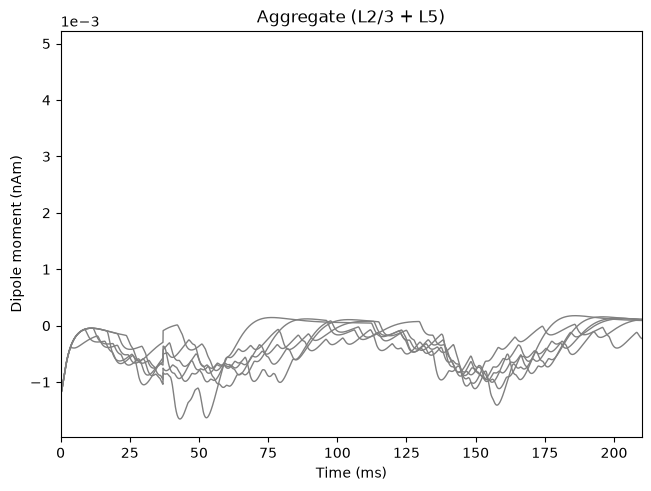

In [7]:
plot_dipole(dpls, show=False)
plt.show()